# 15 · Tabla maestra y gráficas

**Proyecto:** EmoGol — Trabajo de grado, Universidad del Cauca  
**Autor:** Santiago Fernando Ortega Segura · **Director:** Ph.D. Oscar Mauricio Caicedo Rendón

Consolida los resultados de los 18 modelos en la tabla maestra comparativa y genera las gráficas.

*Nombre durante el desarrollo: `11_Consolidacion_Graficas` (algunas salidas conservan esa numeración).*

## 1. Instalar dependencias

In [ ]:
!pip install -q -U "huggingface_hub<2.0" "pandas<3" matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 65.5 MB/s eta 0:00:00


## 2. Configuración y descarga de los 3 archivos de resultados

In [ ]:
from google.colab import userdata, files
from huggingface_hub import login, hf_hub_download

login(token=userdata.get('HF_TOKEN'))

TU_USUARIO_HF = "santiagortegasegura"
REPO_DATOS = f"{TU_USUARIO_HF}/emotion-futbol-data"

ARCHIVOS = {
    "clasico": "final/08_resultados_clasicos.csv",
    "bert_family": "final/09_resultados_bert_family.csv",
    "slm_llm": "final/07_resultados_finales.csv",
}

rutas_locales = {}
for familia, nombre_archivo in ARCHIVOS.items():
    try:
        rutas_locales[familia] = hf_hub_download(
            repo_id=REPO_DATOS, repo_type="dataset", filename=nombre_archivo
        )
        print(f"Descargado de Hugging Face: {nombre_archivo}")
    except Exception as e:
        print(f"No se encontró '{nombre_archivo}' en tu bodega ({e}).")
        print(f"Súbelo a mano en el diálogo que aparece abajo:")
        subido = files.upload()
        rutas_locales[familia] = list(subido.keys())[0]

## 3. Cargar y normalizar las tres tablas a un esquema común

In [ ]:
import pandas as pd

df_clasico = pd.read_csv(rutas_locales["clasico"])
df_bert = pd.read_csv(rutas_locales["bert_family"])
df_slm = pd.read_csv(rutas_locales["slm_llm"])

df_clasico["familia"] = "clasico"
df_bert["familia"] = "bert_family"
df_slm["familia"] = "slm_llm"

df_clasico = df_clasico.rename(columns={
    "memoria_pico_mb": "memoria_mb", "almacenamiento_modelo_mb": "almacenamiento_mb",
})
df_bert = df_bert.rename(columns={
    "memoria_pico_mb": "memoria_mb", "almacenamiento_modelo_mb": "almacenamiento_mb",
})
df_slm = df_slm.rename(columns={
    "memoria_gpu_pico_mb": "memoria_mb", "almacenamiento_adaptador_mb": "almacenamiento_mb",
})

COLUMNAS_COMUNES = [
    "modelo", "familia", "n_test", "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted", "latencia_prom_seg",
    "latencia_lote_prom_seg", "memoria_mb", "almacenamiento_mb", "rouge_l_promedio",
    "bleu1_promedio", "f1_alegria", "f1_tristeza", "f1_enojo", "f1_miedo", "f1_sorpresa",
    "f1_burla", "f1_neutral",
]

tabla_maestra = pd.concat([df_clasico, df_bert, df_slm], ignore_index=True)
for col in COLUMNAS_COMUNES:
    if col not in tabla_maestra.columns:
        tabla_maestra[col] = pd.NA

tabla_maestra["latencia_comparable_seg"] = tabla_maestra["latencia_prom_seg"]
es_slm_llm = tabla_maestra["familia"] == "slm_llm"
tabla_maestra.loc[es_slm_llm, "latencia_comparable_seg"] = tabla_maestra.loc[es_slm_llm, "latencia_lote_prom_seg"]

tabla_maestra = tabla_maestra.sort_values("f1_macro", ascending=False).reset_index(drop=True)

tabla_maestra.to_csv("tabla_maestra_comparativa.csv", index=False)
print(f"Tabla maestra: {len(tabla_maestra)} modelos ({tabla_maestra['familia'].value_counts().to_dict()})")
tabla_maestra

## 4. Ranking de los 6 modelos clásicos

In [ ]:
tradicionales = tabla_maestra[tabla_maestra["familia"] == "clasico"].sort_values(
    "f1_macro", ascending=False
)[["modelo", "accuracy", "f1_macro", "precision_macro", "recall_macro"]].reset_index(drop=True)

print("Ranking de los 6 modelos tradicionales (por F1 macro):")
display(tradicionales)

mejor = tradicionales.iloc[0]
peor = tradicionales.iloc[-1]
print(f"\nMejor modelo tradicional para clasificar emociones: '{mejor['modelo']}' "
      f"(F1 macro={mejor['f1_macro']:.4f}, accuracy={mejor['accuracy']:.4f}).")
print(f"Peor modelo tradicional: '{peor['modelo']}' (F1 macro={peor['f1_macro']:.4f}) -- si es GNN, "
      f"recuerda que ya se documentó como un resultado negativo genuino (loss congelado en ln(7), "
      f"la red nunca aprendió más allá de la inicialización), no un problema de la muestra.")

## 5. Gráficas de barras

/tmp/ipykernel_2300/2506416068.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datos["modelo"], rotation=45, ha="right")


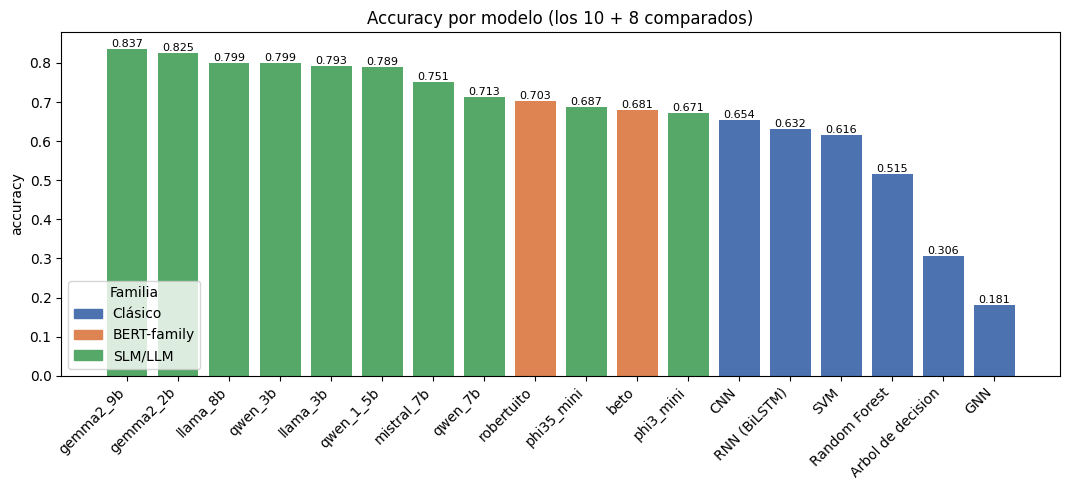

/tmp/ipykernel_2300/2506416068.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datos["modelo"], rotation=45, ha="right")


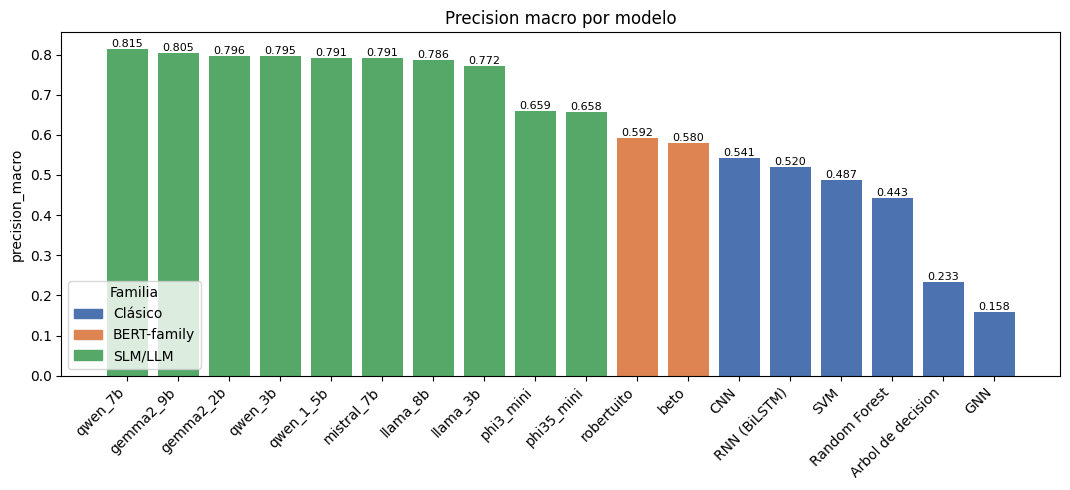

/tmp/ipykernel_2300/2506416068.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datos["modelo"], rotation=45, ha="right")


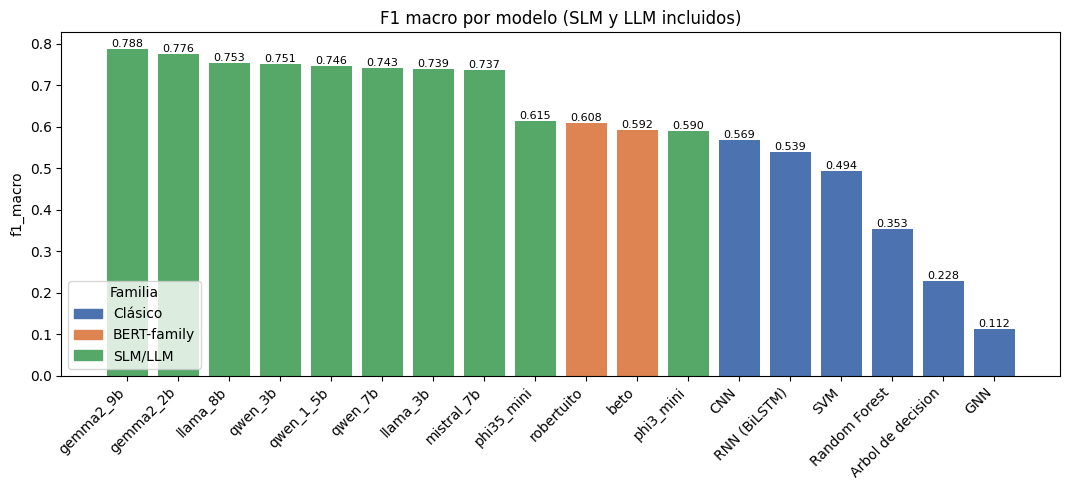

In [ ]:
import matplotlib.pyplot as plt

COLOR_FAMILIA = {"clasico": "#4C72B0", "bert_family": "#DD8452", "slm_llm": "#55A868"}
ETIQUETA_FAMILIA = {"clasico": "Clásico", "bert_family": "BERT-family", "slm_llm": "SLM/LLM"}

def grafica_barras(columna, titulo, archivo_salida, solo_familias=None):
    datos = tabla_maestra.dropna(subset=[columna])
    if solo_familias:
        datos = datos[datos["familia"].isin(solo_familias)]
    datos = datos.sort_values(columna, ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(datos) * 0.6), 5))
    colores = [COLOR_FAMILIA[f] for f in datos["familia"]]
    barras = ax.bar(datos["modelo"], datos[columna], color=colores)
    ax.set_title(titulo)
    ax.set_ylabel(columna)
    ax.set_xticklabels(datos["modelo"], rotation=45, ha="right")
    for barra, valor in zip(barras, datos[columna]):
        ax.text(barra.get_x() + barra.get_width() / 2, valor, f"{valor:.3f}",
                ha="center", va="bottom", fontsize=8)

    manejadores = [plt.Rectangle((0, 0), 1, 1, color=COLOR_FAMILIA[f]) for f in COLOR_FAMILIA]
    ax.legend(manejadores, ETIQUETA_FAMILIA.values(), title="Familia", loc="lower left")
    fig.tight_layout()
    fig.savefig(archivo_salida, dpi=150)
    plt.show()

grafica_barras("accuracy", "Accuracy por modelo (los 10 + 8 comparados)", "grafica_accuracy.png")
grafica_barras("precision_macro", "Precision macro por modelo", "grafica_precision_macro.png")
grafica_barras("f1_macro", "F1 macro por modelo (SLM y LLM incluidos)", "grafica_f1_macro.png")

/tmp/ipykernel_2300/2506416068.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datos["modelo"], rotation=45, ha="right")


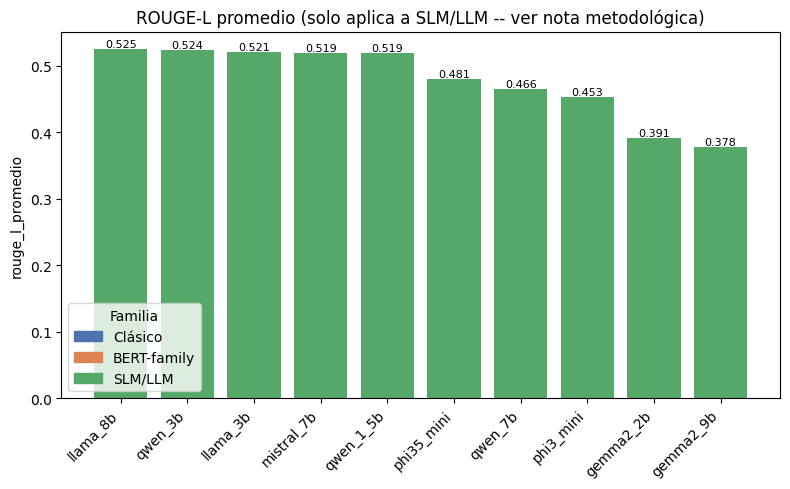

/tmp/ipykernel_2300/2506416068.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datos["modelo"], rotation=45, ha="right")


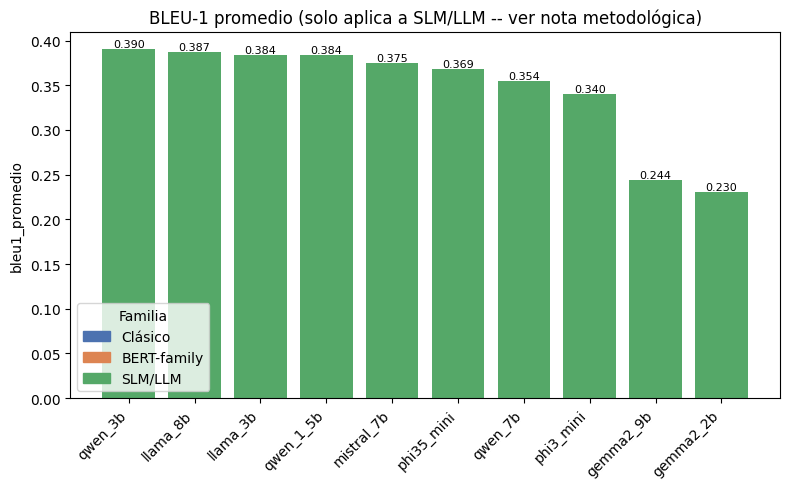

In [ ]:
grafica_barras("rouge_l_promedio", "ROUGE-L promedio (solo aplica a SLM/LLM -- ver nota metodológica)",
               "grafica_rouge_l.png", solo_familias=["slm_llm"])
grafica_barras("bleu1_promedio", "BLEU-1 promedio (solo aplica a SLM/LLM -- ver nota metodológica)",
               "grafica_bleu1.png", solo_familias=["slm_llm"])

## 6. Gráficas de compromiso (trade-off)

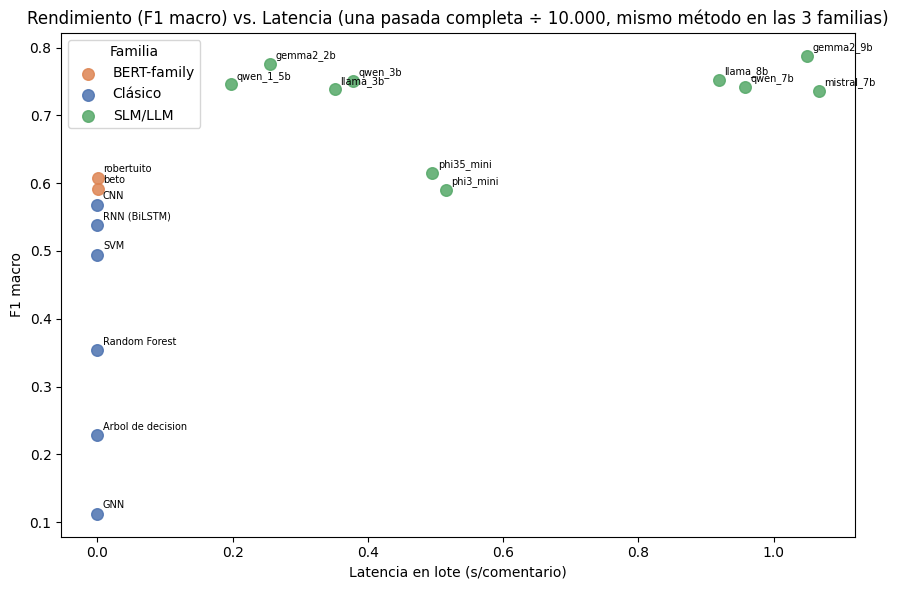

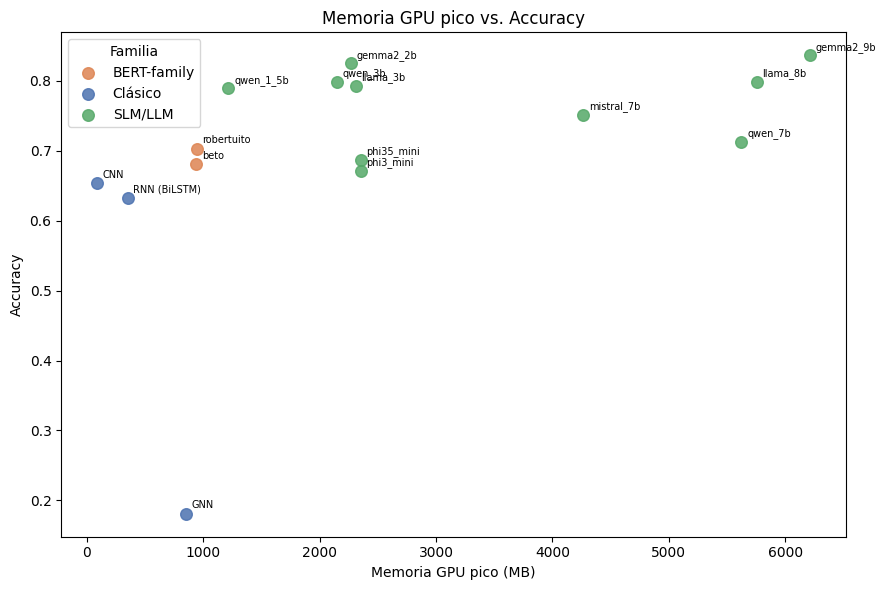

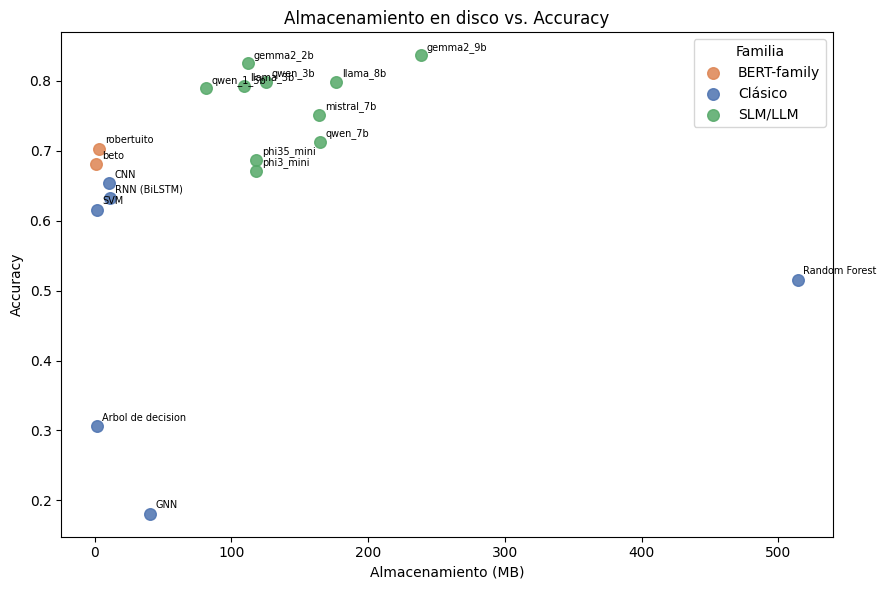

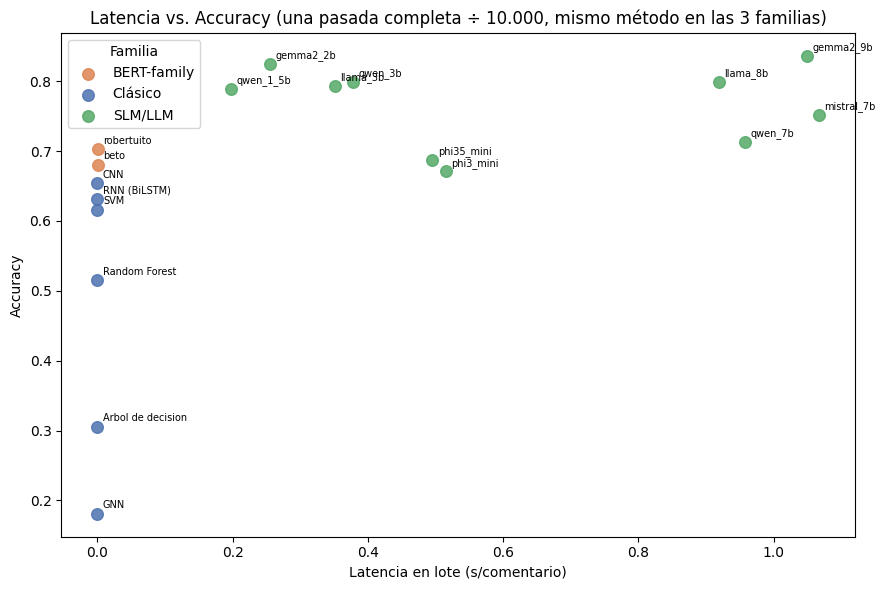

In [ ]:
def grafica_dispersión(col_x, col_y, titulo, archivo_salida, etiqueta_x=None, etiqueta_y=None):
    datos = tabla_maestra.dropna(subset=[col_x, col_y])
    fig, ax = plt.subplots(figsize=(9, 6))
    for familia, grupo in datos.groupby("familia"):
        ax.scatter(grupo[col_x], grupo[col_y], color=COLOR_FAMILIA[familia],
                   label=ETIQUETA_FAMILIA[familia], s=70, alpha=0.85)
        for _, fila in grupo.iterrows():
            ax.annotate(fila["modelo"], (fila[col_x], fila[col_y]),
                        fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel(etiqueta_x or col_x)
    ax.set_ylabel(etiqueta_y or col_y)
    ax.set_title(titulo)
    ax.legend(title="Familia")
    fig.tight_layout()
    fig.savefig(archivo_salida, dpi=150)
    plt.show()

grafica_dispersión("latencia_comparable_seg", "f1_macro",
                   "Rendimiento (F1 macro) vs. Latencia (una pasada completa ÷ 10.000, mismo método en las 3 familias)",
                   "grafica_f1_vs_latencia.png",
                   etiqueta_x="Latencia en lote (s/comentario)", etiqueta_y="F1 macro")

grafica_dispersión("memoria_mb", "accuracy",
                   "Memoria GPU pico vs. Accuracy", "grafica_memoria_vs_accuracy.png",
                   etiqueta_x="Memoria GPU pico (MB)", etiqueta_y="Accuracy")

grafica_dispersión("almacenamiento_mb", "accuracy",
                   "Almacenamiento en disco vs. Accuracy", "grafica_almacenamiento_vs_accuracy.png",
                   etiqueta_x="Almacenamiento (MB)", etiqueta_y="Accuracy")

grafica_dispersión("latencia_comparable_seg", "accuracy",
                   "Latencia vs. Accuracy (una pasada completa ÷ 10.000, mismo método en las 3 familias)",
                   "grafica_latencia_vs_accuracy.png",
                   etiqueta_x="Latencia en lote (s/comentario)", etiqueta_y="Accuracy")

## 7. Subir la tabla maestra y las gráficas a Hugging Face

In [ ]:
from huggingface_hub import upload_file
import glob

upload_file(path_or_fileobj="tabla_maestra_comparativa.csv", path_in_repo="final/tabla_maestra_comparativa.csv",
            repo_id=REPO_DATOS, repo_type="dataset")

for archivo_png in glob.glob("grafica_*.png"):
    upload_file(path_or_fileobj=archivo_png, path_in_repo=f"final/graficas/{archivo_png}",
                repo_id=REPO_DATOS, repo_type="dataset")

print("Tabla maestra y gráficas subidas a tu bodega de datos en Hugging Face (carpeta 'graficas/').")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/grafica_rouge_l.png: 100%|##########| 71.5kB / 71.5kB            

Validating                    :           |   0%            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...enamiento_vs_accuracy.png: 100%|##########| 79.0kB / 79.0kB            

Validating                    :           |   0%            

Tabla maestra y gráficas subidas a tu bodega de datos en Hugging Face (carpeta 'graficas/').
